In [25]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from IPython.display import display, HTML

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np


import joblib

warnings.filterwarnings("ignore")

# Just to do a t-test
from scipy.stats import ttest_rel


from lime.lime_tabular import LimeTabularExplainer

%matplotlib inline

# 1. Understand the Variables (EDA)

In [2]:
med_df = pd.read_csv("../historical.csv")
X = med_df.iloc[:, :-1]
y = med_df.iloc[:, -1]

## a. Check for missing variables and deal with variables that are only for the first day

All variables in the dataset have complete values except for `apgar_score`, which is missing for most entries because it is only recorded on the first day after birth. Other variables also specific to the first day include `birth_weight_kg`, `birth_length_cm`, and `birth_head_circumference_cm`. However, this creates some confusion because the dataset also contains `weight_kg`, `length_cm`, and `head_circumference_cm`, which are measured on the first day and then tracked daily for up to 30 days.

What is more puzzling is that the two sets of measurements often do not match. For instance, baby **B001** has a recorded birth weight of 3.30 kg, but their first-day weight is listed as 3.28 kg. This suggests that the same measurements were repeated but recorded differently. To check whether these paired variables are consistent with one another, we will perform t-tests comparing birth weight with first-day weight, birth length with first-day length, and birth head circumference with first-day head circumference.

In [44]:
is_first_day = med_df['age_days'] == 1

var_pairs = [
    ('birth_weight_kg', 'weight_kg'),
    ('birth_length_cm', 'length_cm'),
    ('birth_head_circumference_cm', 'head_circumference_cm')
    ]

for var_pair in var_pairs:
    # Just get the text
    birth_var = var_pair[0]
    first_day_var = var_pair[1]

    birth_measures = med_df.loc[is_first_day, birth_var]
    first_day_measures = med_df.loc[is_first_day, first_day_var]

    t_stat, p_value = ttest_rel(birth_measures, first_day_measures)

    if p_value < 0.00001:
        print(f'{birth_var} and {first_day_var} on the first day '
              'are significantly different.')
    else:
        print(f'{birth_var} and {first_day_var} on the first day '
              'have no significant difference.')

birth_weight_kg and weight_kg on the first day have no significant difference.
birth_length_cm and length_cm on the first day have no significant difference.
birth_head_circumference_cm and head_circumference_cm on the first day have no significant difference.


In [41]:
med_df.loc[is_first_day, ['birth_length_cm', 'length_cm']].mean()

birth_length_cm    49.564286
length_cm          49.610000
dtype: float64

In [42]:
med_df.loc[is_first_day, ['birth_length_cm', 'length_cm']].std()

birth_length_cm    2.067067
length_cm          2.089737
dtype: float64

array([[<Axes: title={'center': 'birth_weight_kg'}>,
        <Axes: title={'center': 'weight_kg'}>]], dtype=object)

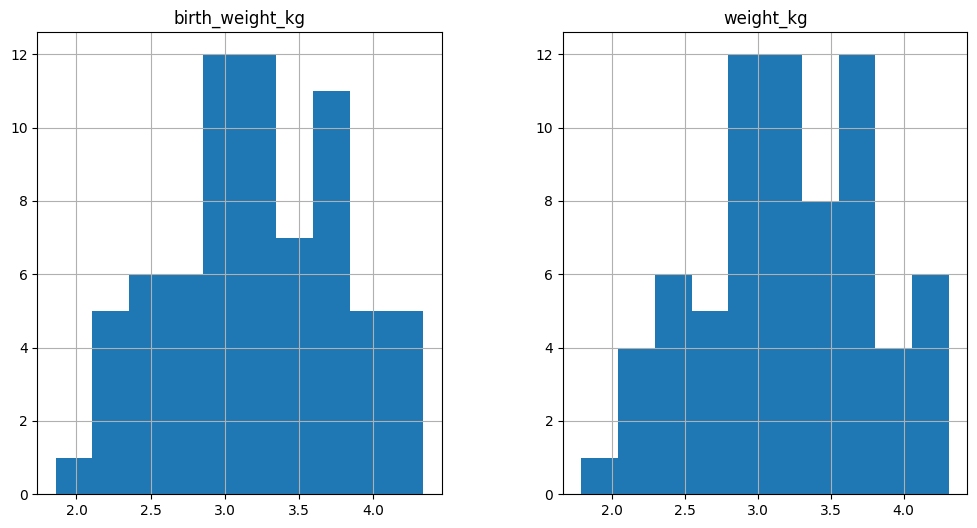

In [31]:
med_df.loc[is_first_day, ['birth_weight_kg', 'weight_kg']].hist(figsize=(12, 6))

In [20]:
med_df_sorted = med_df.sort_values(["baby_id", "date"])

pivoted = med_df_sorted.pivot_table(
    index=["baby_id", "date"],   # keeps baby + date as rows
    values=["birth_head_circumference_cm", "head_circumference_cm", "age_days"],  # columns from these
    aggfunc="first"              # if duplicates per date exist
)
pivoted.loc['B050']

,age_days,birth_head_circumference_cm,head_circumference_cm
date,,,
2025-04-28,1,32.5,32.6
2025-04-29,2,32.5,32.5
2025-04-30,3,32.5,32.7
2025-05-01,4,32.5,32.5
2025-05-02,5,32.5,32.7
2025-05-03,6,32.5,32.7
2025-05-04,7,32.5,32.7
2025-05-05,8,32.5,32.6
2025-05-06,9,32.5,32.8


In [18]:
med_df_sorted = med_df.sort_values(["baby_id", "date"])

pivoted = med_df_sorted.pivot_table(
    index=["baby_id", "date"],   # keeps baby + date as rows
    values=["birth_weight_kg", "weight_kg", "apgar_score", "age_days"],  # columns from these
    aggfunc="first"              # if duplicates per date exist
)
pivoted.loc['B050']

,age_days,apgar_score,birth_weight_kg,weight_kg
date,,,,
2025-04-28,1,7.0,2.87,2.89
2025-04-29,2,NaN,2.87,2.91
2025-04-30,3,NaN,2.87,2.97
2025-05-01,4,NaN,2.87,3.02
2025-05-02,5,NaN,2.87,2.99
2025-05-03,6,NaN,2.87,3.10
2025-05-04,7,NaN,2.87,3.09
2025-05-05,8,NaN,2.87,3.04
2025-05-06,9,NaN,2.87,3.12


In [6]:
med_df[['birth_weight_kg', 'weight_kg']]

,birth_weight_kg,weight_kg
0,3.30,3.28
1,3.30,3.35
2,3.30,3.35
3,3.30,3.48
4,3.30,3.50
...,...,...
2095,4.21,4.99
2096,4.21,5.04
2097,4.21,5.05
2098,4.21,5.03


In [3]:
med_df.isnull().sum() / med_df.shape[0]

baby_id                        0.000000
name                           0.000000
gender                         0.000000
gestational_age_weeks          0.000000
birth_weight_kg                0.000000
birth_length_cm                0.000000
birth_head_circumference_cm    0.000000
date                           0.000000
age_days                       0.000000
weight_kg                      0.000000
length_cm                      0.000000
head_circumference_cm          0.000000
temperature_c                  0.000000
heart_rate_bpm                 0.000000
respiratory_rate_bpm           0.000000
oxygen_saturation              0.000000
feeding_type                   0.000000
feeding_frequency_per_day      0.000000
urine_output_count             0.000000
stool_count                    0.000000
jaundice_level_mg_dl           0.000000
apgar_score                    0.966667
immunizations_done             0.000000
reflexes_normal                0.000000
risk_level                     0.000000


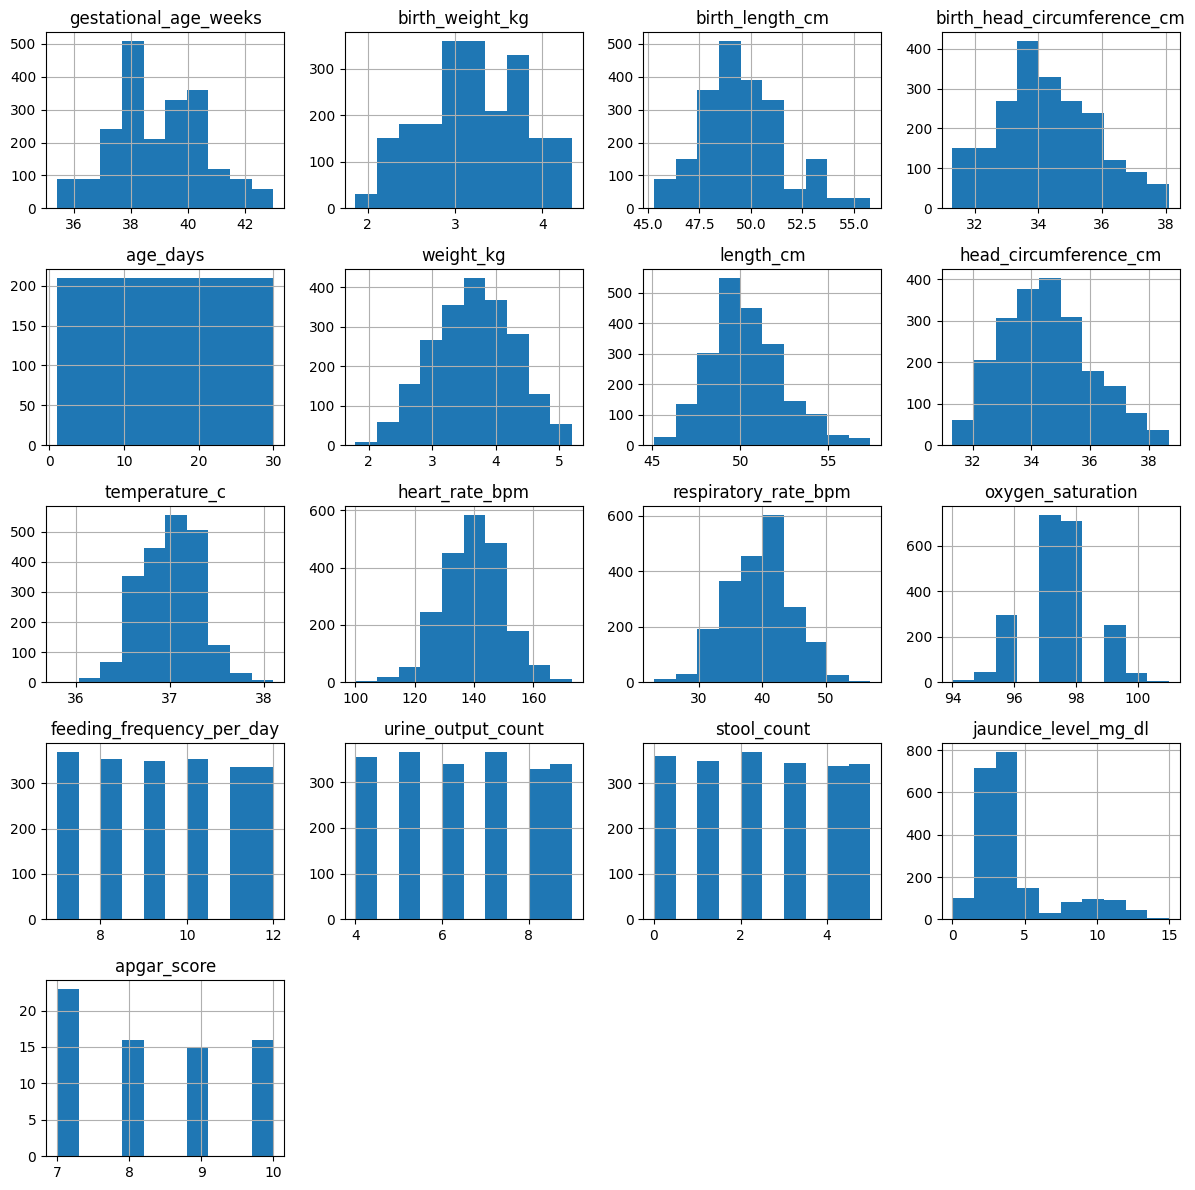

In [13]:
df.hist(figsize=(12, 12))
plt.tight_layout()

# 2. How Does the Model Work?

## a. Reverse Engineer the Model

### i. Recreate the Column Transformer

In [97]:
# define what are the numerical and categorical features 
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=['number']).columns

# Pipeline for numerical features
num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Temporary just so that we can determine the names of the onehot encoded variables
temp_cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        drop='if_binary',
        # Remove once actually doing the work
        sparse_output=False))
])
temp_cat_transformer.fit(X[cat_cols])
cat_transformed_names = list(temp_cat_transformer['onehot'].get_feature_names_out())
all_transformed_names = num_cols.to_list() + cat_transformed_names

# Pipeline for categorical features
cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        drop='if_binary',
        sparse_output=True))
])

# Combine the two transformers
preprocessor = ColumnTransformer(
    transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols) 
    ])

X_preprocessed = preprocessor.fit_transform(X)

In [98]:
old_model = joblib.load("../model.joblib")
old_model

,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## b. Explain why the babies were misclassified